In [1]:
# ============================================
# MoCo (v2-style) Training + Eval on Fish Data
# (kept consistent with your BYOL pipeline)
# ============================================

import os
import random
import shutil
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# 0) Repro / Device
# -----------------------------
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.backends.cudnn.benchmark = True


In [2]:

# -----------------------------
# 1) Paths & Split (same as BYOL)
# -----------------------------
root_dir = "/kaggle/input/fish-classification-dataset/Fish Data"
working_dir = "/kaggle/working/fish_dataset_split_moco"   # separate working dir for MoCo run

train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
splits = ["train", "val", "test"]

os.makedirs(working_dir, exist_ok=True)
for s in splits:
    os.makedirs(os.path.join(working_dir, s), exist_ok=True)

# Only build the split if it's empty (prevents duplicate copies)
needs_split = False
for s in splits:
    split_path = os.path.join(working_dir, s)
    if len(os.listdir(split_path)) == 0:
        needs_split = True

if needs_split:
    for cls in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(class_dir):
            continue

        raw_folders = ["Raw", "Raw Data"]
        images = []
        for rf in raw_folders:
            path = os.path.join(class_dir, rf)
            if os.path.exists(path):
                images.extend([p for p in glob(os.path.join(path, "*")) if os.path.isfile(p)])

        if len(images) == 0:
            continue

        random.shuffle(images)
        n = len(images)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        n_test = n - n_train - n_val

        assigns = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for s in splits:
            dest_dir = os.path.join(working_dir, s, cls)
            os.makedirs(dest_dir, exist_ok=True)
            for p in assigns[s]:
                try:
                    shutil.copy(p, dest_dir)
                except Exception as e:
                    # Skip unreadable files
                    pass
    print("✅ Dataset split created in:", working_dir)
else:
    print("ℹ️ Using existing split in:", working_dir)



✅ Dataset split created in: /kaggle/working/fish_dataset_split_moco


In [3]:
# -----------------------------
# 2) Transforms (match BYOL style)
# -----------------------------
# Strong augments for self-supervised pretraining
pretrain_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor()
])

# Light augments for classifier fine-tuning/eval
clf_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])



In [4]:
# -----------------------------
# 3) Two-views dataset for MoCo
# -----------------------------
from PIL import Image

class ImageFolderTwoViews(ImageFolder):
    """Returns (view1, view2), label from a single image path using the same base transform twice."""
    def __init__(self, root, base_transform):
        super().__init__(root, transform=None)
        self.base_transform = base_transform

    def __getitem__(self, index):
        path, target = self.samples[index]
        img = self.loader(path)
        if isinstance(img, Image.Image) is False:
            img = Image.open(path).convert("RGB")
        im1 = self.base_transform(img)
        im2 = self.base_transform(img)
        return (im1, im2), target



In [5]:
# -----------------------------
# 4) Datasets & Loaders
# -----------------------------
batch_size = 64
num_workers = 4 if device == "cuda" else 2
pin_memory = device == "cuda"

# Pretraining dataset: train split with two views
pretrain_dataset = ImageFolderTwoViews(os.path.join(working_dir, "train"), base_transform=pretrain_transform)
pretrain_loader = DataLoader(pretrain_dataset, batch_size=batch_size, shuffle=True, drop_last=True,
                             num_workers=num_workers, pin_memory=pin_memory)

# Classifier datasets (same as your improved BYOL stage)
train_dataset = ImageFolder(os.path.join(working_dir, "train"), transform=clf_transform)
val_dataset   = ImageFolder(os.path.join(working_dir, "val"),   transform=clf_transform)
test_dataset  = ImageFolder(os.path.join(working_dir, "test"),  transform=clf_transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  drop_last=True,
                          num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers, pin_memory=pin_memory)

num_classes = len(train_dataset.classes)
print("Classes:", train_dataset.classes)



Classes: ['Aair', 'Boal', 'Chapila', 'DeshiPuti', 'Foli', 'Ilish', 'KalBaush', 'Katla', 'Koi', 'Magur', 'Mrigel', 'Pabda', 'Pangas', 'Puti', 'Rui', 'Shol', 'Taki', 'Tarabaim', 'Telapiya', 'Tengra']


In [6]:
# -----------------------------
# 5) MoCo (v2-style) Model
# -----------------------------
class ResNetBackbone(nn.Module):
    """ResNet18 backbone that returns a 512-d feature vector (fc replaced by Identity)."""
    def __init__(self):
        super().__init__()
        m = resnet18(pretrained=False)
        m.fc = nn.Identity()
        self.encoder = m

    def forward(self, x):
        return self.encoder(x)  # (N, 512)

class MLPHead(nn.Module):
    """MoCo v2 projection head: 512 -> 2048 -> 128"""
    def __init__(self, in_dim=512, hidden=2048, out_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.net(x)

class MoCo(nn.Module):
    """
    Minimal single-GPU MoCo v2:
      - momentum encoder (key) updated by EMA
      - queue of negative keys
      - InfoNCE loss (CE with temperature)
    """
    def __init__(self, feature_dim=128, K=16384, m=0.99, T=0.07):
        super().__init__()
        self.K = K
        self.m = m
        self.T = T

        # Encoders (output 512-d features)
        self.encoder_q = ResNetBackbone()
        self.encoder_k = ResNetBackbone()

        # Projection heads to 128-d
        self.mlp_q = MLPHead(in_dim=512, hidden=2048, out_dim=feature_dim)
        self.mlp_k = MLPHead(in_dim=512, hidden=2048, out_dim=feature_dim)

        # Copy params from q -> k
        for p_q, p_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            p_k.data.copy_(p_q.data)
            p_k.requires_grad = False
        for p_q, p_k in zip(self.mlp_q.parameters(), self.mlp_k.parameters()):
            p_k.data.copy_(p_q.data)
            p_k.requires_grad = False

        # Create the queue
        self.register_buffer("queue", torch.randn(feature_dim, K))
        self.queue = nn.functional.normalize(self.queue, dim=0)
        self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _momentum_update_key_encoder(self):
        """EMA update for key encoder and its MLP head."""
        for p_q, p_k in zip(self.encoder_q.parameters(), self.encoder_k.parameters()):
            p_k.data = p_k.data * self.m + p_q.data * (1. - self.m)
        for p_q, p_k in zip(self.mlp_q.parameters(), self.mlp_k.parameters()):
            p_k.data = p_k.data * self.m + p_q.data * (1. - self.m)

    @torch.no_grad()
    def _dequeue_and_enqueue(self, keys):
        """keys: (N, C) already L2-normalized"""
        batch_size = keys.shape[0]
        ptr = int(self.queue_ptr)

        end = ptr + batch_size
        if end <= self.K:
            self.queue[:, ptr:end] = keys.T
        else:
            first_len = self.K - ptr
            self.queue[:, ptr:] = keys[:first_len].T
            self.queue[:, :end - self.K] = keys[first_len:].T

        self.queue_ptr[0] = (end) % self.K

    def forward(self, im_q, im_k):
        """
        im_q, im_k: (N, C, H, W)
        Returns CE logits and labels=0 (pos at idx 0).
        """
        # Query branch
        q_feat = self.encoder_q(im_q)                # (N, 512)
        q = self.mlp_q(q_feat)                       # (N, 128)
        q = nn.functional.normalize(q, dim=1)

        with torch.no_grad():
            self._momentum_update_key_encoder()
            k_feat = self.encoder_k(im_k)            # (N, 512)
            k = self.mlp_k(k_feat)                   # (N, 128)
            k = nn.functional.normalize(k, dim=1)

        # Positive logits: q · k
        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)  # (N,1)

        # Negative logits: q · queue
        l_neg = torch.einsum('nc,ck->nk', [q, self.queue.clone().detach()])  # (N,K)

        # Logits: [pos | neg]
        logits = torch.cat([l_pos, l_neg], dim=1) / self.T
        labels = torch.zeros(logits.shape[0], dtype=torch.long, device=logits.device)

        # Update queue
        with torch.no_grad():
            self._dequeue_and_enqueue(k)

        return logits, labels



In [7]:
# -----------------------------
# 6) Pretrain MoCo on train split
# -----------------------------
moco = MoCo(feature_dim=128, K=16384, m=0.99, T=0.07).to(device)
optimizer = optim.Adam(moco.parameters(), lr=1e-3)
epochs_ssl = 10  # keep same as BYOL for fair comparison

moco.train()
for epoch in range(epochs_ssl):
    total_loss = 0.0
    for (im1, im2), _ in pretrain_loader:
        im_q = im1.to(device, non_blocking=True)
        im_k = im2.to(device, non_blocking=True)

        logits, labels = moco(im_q, im_k)
        loss = nn.CrossEntropyLoss()(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs_ssl}], MoCo Loss: {total_loss/len(pretrain_loader):.4f}")

# Save ONLY the backbone (encoder_q) to compare with BYOL backbone usage
torch.save(moco.encoder_q.state_dict(), "moco_fish_backbone.pth")
print("✅ MoCo pretraining finished. Saved backbone -> moco_fish_backbone.pth")



/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/10], MoCo Loss: 5.2205
Epoch [2/10], MoCo Loss: 5.1801
Epoch [3/10], MoCo Loss: 5.0956
Epoch [4/10], MoCo Loss: 4.9760
Epoch [5/10], MoCo Loss: 4.8401
Epoch [6/10], MoCo Loss: 4.7784
Epoch [7/10], MoCo Loss: 4.6450
Epoch [8/10], MoCo Loss: 4.5317
Epoch [9/10], MoCo Loss: 4.3522
Epoch [10/10], MoCo Loss: 4.2470
✅ MoCo pretraining finished. Saved backbone -> moco_fish_backbone.pth


In [8]:
# -----------------------------
# 7) Linear/classifier fine-tuning (same strategy as BYOL improved)
#    - Unfreeze layer4
#    - 5 epochs
#    - StepLR
#    - Track best val acc
# -----------------------------
# Build a fresh backbone and load MoCo weights
backbone = resnet18(pretrained=False)
backbone.fc = nn.Identity()
missing, unexpected = backbone.load_state_dict(moco.encoder_q.state_dict(), strict=False)
print("Loaded MoCo backbone. Missing:", missing, "| Unexpected:", unexpected)
backbone = backbone.to(device)

# Unfreeze only layer4
for name, p in backbone.named_parameters():
    p.requires_grad = ("layer4" in name)

classifier = nn.Linear(512, num_classes).to(device)

params_to_opt = list(classifier.parameters()) + [p for p in backbone.parameters() if p.requires_grad]
optimizer_cls = optim.Adam(params_to_opt, lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer_cls, step_size=10, gamma=0.5)

criterion = nn.CrossEntropyLoss()
epochs_cls = 5

best_val_acc = 0.0
best_states = None

for epoch in range(epochs_cls):
    backbone.train()
    classifier.train()
    total_loss = 0.0
    correct = 0

    for images, labels in train_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        feats = backbone(images)          # (N, 512)
        logits = classifier(feats)        # (N, C)
        loss = criterion(logits, labels)

        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()

        total_loss += loss.item()
        correct += (logits.argmax(1) == labels).sum().item()

    train_acc = correct / len(train_dataset)
    print(f"Epoch [{epoch+1}/{epochs_cls}] Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.4f}")

    # Validation
    backbone.eval()
    classifier.eval()
    v_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            feats = backbone(images)
            logits = classifier(feats)
            v_correct += (logits.argmax(1) == labels).sum().item()
    val_acc = v_correct / len(val_dataset)
    print(f"Validation Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_states = {
            "backbone": backbone.state_dict(),
            "classifier": classifier.state_dict()
        }

    scheduler.step()

print(f"✅ Best Validation Accuracy: {best_val_acc:.4f}")



Loaded MoCo backbone. Missing: ['conv1.weight', 'bn1.weight', 'bn1.bias', 'bn1.running_mean', 'bn1.running_var', 'layer1.0.conv1.weight', 'layer1.0.bn1.weight', 'layer1.0.bn1.bias', 'layer1.0.bn1.running_mean', 'layer1.0.bn1.running_var', 'layer1.0.conv2.weight', 'layer1.0.bn2.weight', 'layer1.0.bn2.bias', 'layer1.0.bn2.running_mean', 'layer1.0.bn2.running_var', 'layer1.1.conv1.weight', 'layer1.1.bn1.weight', 'layer1.1.bn1.bias', 'layer1.1.bn1.running_mean', 'layer1.1.bn1.running_var', 'layer1.1.conv2.weight', 'layer1.1.bn2.weight', 'layer1.1.bn2.bias', 'layer1.1.bn2.running_mean', 'layer1.1.bn2.running_var', 'layer2.0.conv1.weight', 'layer2.0.bn1.weight', 'layer2.0.bn1.bias', 'layer2.0.bn1.running_mean', 'layer2.0.bn1.running_var', 'layer2.0.conv2.weight', 'layer2.0.bn2.weight', 'layer2.0.bn2.bias', 'layer2.0.bn2.running_mean', 'layer2.0.bn2.running_var', 'layer2.0.downsample.0.weight', 'layer2.0.downsample.1.weight', 'layer2.0.downsample.1.bias', 'layer2.0.downsample.1.running_mean',

In [9]:
# -----------------------------
# 8) Test evaluation (like BYOL)
# -----------------------------
# Load best states before testing
if best_states is not None:
    backbone.load_state_dict(best_states["backbone"])
    classifier.load_state_dict(best_states["classifier"])
backbone.eval()
classifier.eval()

t_correct = 0
all_preds, all_labels = [], []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        feats = backbone(images)
        logits = classifier(feats)
        probs = torch.softmax(logits, dim=1)

        t_correct += (logits.argmax(1) == labels).sum().item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

test_acc = t_correct / len(test_dataset)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
print(f"🎯 Test Accuracy: {test_acc:.4f}")



🎯 Test Accuracy: 0.8749


<Figure size 1200x1200 with 0 Axes>

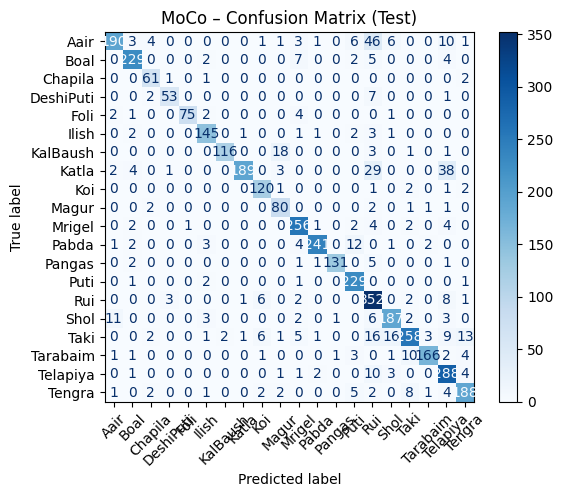

Class Aair ROC-AUC: 0.9903
Class Boal ROC-AUC: 0.9956
Class Chapila ROC-AUC: 0.9992
Class DeshiPuti ROC-AUC: 0.9937
Class Foli ROC-AUC: 0.9987
Class Ilish ROC-AUC: 0.9987
Class KalBaush ROC-AUC: 0.9987
Class Katla ROC-AUC: 0.9956
Class Koi ROC-AUC: 0.9992
Class Magur ROC-AUC: 0.9980
Class Mrigel ROC-AUC: 0.9987
Class Pabda ROC-AUC: 0.9984
Class Pangas ROC-AUC: 0.9991
Class Puti ROC-AUC: 0.9986
Class Rui ROC-AUC: 0.9921
Class Shol ROC-AUC: 0.9928
Class Taki ROC-AUC: 0.9918
Class Tarabaim ROC-AUC: 0.9970
Class Telapiya ROC-AUC: 0.9930
Class Tengra ROC-AUC: 0.9928
Macro-average ROC-AUC: 0.9961


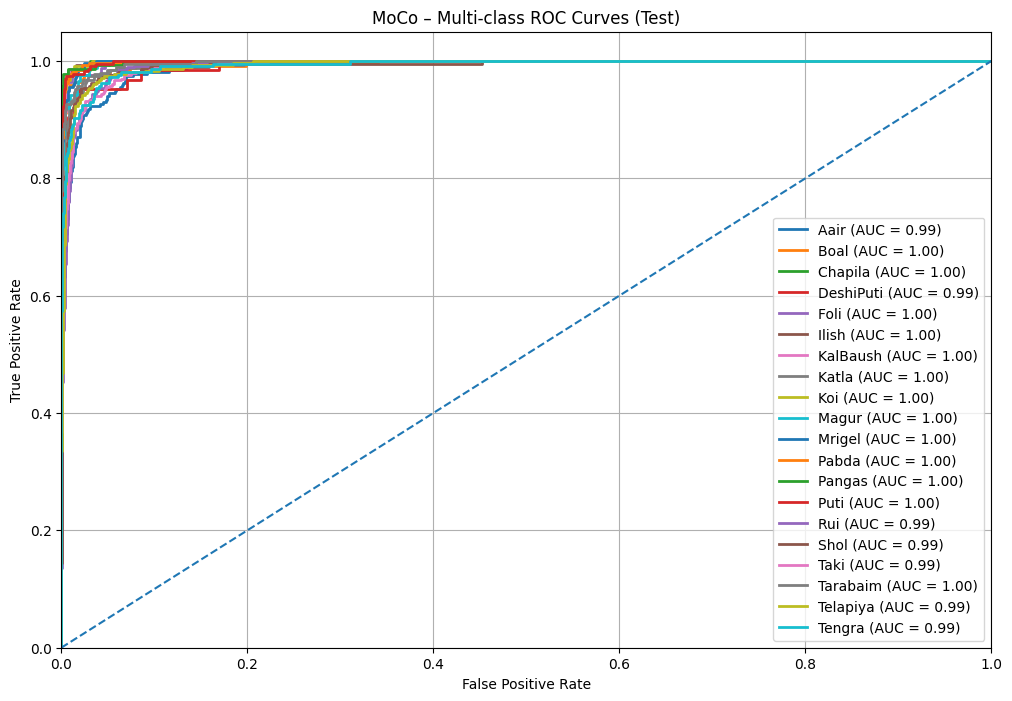

In [10]:
# -----------------------------
# 9) Confusion Matrix (same style)
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=test_dataset.classes)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45, values_format='d')
plt.title("MoCo – Confusion Matrix (Test)")
plt.show()

# -----------------------------
# 10) ROC-AUC (per-class + macro) and ROC Curves
# -----------------------------
num_classes = len(test_dataset.classes)
labels_onehot = label_binarize(all_labels, classes=np.arange(num_classes))

# Per-class ROC-AUC
roc_auc_per_class = roc_auc_score(labels_onehot, all_probs, average=None)
for i, cls in enumerate(test_dataset.classes):
    print(f"Class {cls} ROC-AUC: {roc_auc_per_class[i]:.4f}")
print(f"Macro-average ROC-AUC: {roc_auc_score(labels_onehot, all_probs, average='macro'):.4f}")

# ROC Curves
plt.figure(figsize=(12, 8))
for i, cls in enumerate(test_dataset.classes):
    fpr, tpr, _ = roc_curve(labels_onehot[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlim([0, 1])
plt.ylim([0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('MoCo – Multi-class ROC Curves (Test)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
